# 01 · Data exploration: the Vehicle Energy Dataset (VED)

**Question:** what does real vehicle data look like, and what does that mean for how the analyzer is built?

[VED](https://github.com/gsoh/VED) contains OBD-II logs from 383 personal cars (petrol, hybrid, plug-in hybrid and electric) driven in Ann Arbor, Michigan, between November 2017 and November 2018. This notebook explores the **first 4 weeks** (about 2.1 million readings).

**Contents**
1. Load and clean the data
2. Dataset overview
3. Which signals are recorded (missing data)
4. Signal distributions
5. Differences between vehicles
6. Relationships between signals
7. One example trip
8. Data quality
9. Summary: findings → design decisions

> Requires the VED files: `python scripts/download_ved.py --weeks 4`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "analyzer").exists())
sys.path.insert(0, str(ROOT / "src"))

from analyzer.config import VALID_RANGES
from analyzer.ingestion.cleaner import add_vehicle_info, clean_ved, remove_invalid_values
from analyzer.ingestion.loader import list_ved_files, load_ved, load_vehicle_info

# Chart style: one blue series, recessive grid, no top/right spines
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
BAND = "#cde2fb"            # light blue for "normal range" shading
TEXT, TEXT_2, GRID = "#0b0b0b", "#52514e", "#e8e7e3"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": TEXT_2, "axes.titlecolor": TEXT,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": TEXT_2, "ytick.color": TEXT_2, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "lines.linewidth": 2, "legend.frameon": False, "font.size": 10,
})
pd.set_option("display.float_format", "{:,.2f}".format)
TRIP = ["vehicle_id", "trip_id"]

## 1. Load and clean the data

The project's own loader and cleaner (`src/analyzer/ingestion/`) are used, so the notebook sees exactly what the pipeline sees. Cleaning: rename columns, drop duplicate readings, sort each trip by time, blank out physically impossible values, drop rows with neither speed nor RPM, add timestamps and vehicle type.

In [2]:
WEEKS = 4
raw = load_ved(weeks=WEEKS)
vehicles = load_vehicle_info()
df = add_vehicle_info(clean_ved(raw), vehicles)

print(f"raw readings:   {len(raw):,}")
print(f"clean readings: {len(df):,}  ({len(raw) - len(df):,} removed)")
df.head()

raw readings:   2,101,033
clean readings: 2,099,637  (1,396 removed)


,day_num,vehicle_id,trip_id,time_ms,latitude,longitude,speed_kmh,maf_gs,engine_rpm,absolute_load_pct,...,hv_battery_current_a,hv_battery_soc_pct,hv_battery_voltage_v,stft_b1_pct,stft_b2_pct,ltft_b1_pct,ltft_b2_pct,timestamp,vehicle_type,vehicle_class
0,9.56,2,685,0,42.30,-83.70,27.00,18.39,"1,446.00",13.33,...,NaN,NaN,NaN,-3.12,NaN,10.16,NaN,2017-11-09 13:23:40.605,ICE,Car
1,9.56,2,685,700,42.30,-83.70,27.00,18.39,"1,446.00",70.20,...,NaN,NaN,NaN,-3.12,NaN,10.16,NaN,2017-11-09 13:23:41.305,ICE,Car
2,9.56,2,685,1000,42.30,-83.70,30.00,18.39,"1,446.00",70.20,...,NaN,NaN,NaN,-3.12,NaN,10.16,NaN,2017-11-09 13:23:41.605,ICE,Car
3,9.56,2,685,2500,42.30,-83.70,33.00,20.20,"1,475.00",70.20,...,NaN,NaN,NaN,-2.34,NaN,10.16,NaN,2017-11-09 13:23:43.105,ICE,Car
4,9.56,2,685,2900,42.30,-83.70,33.00,20.20,"1,475.00",70.20,...,NaN,NaN,NaN,-2.34,NaN,10.16,NaN,2017-11-09 13:23:43.505,ICE,Car


## 2. Dataset overview

In [3]:
trips = df.groupby(TRIP).agg(
    vehicle_type=("vehicle_type", "first"),
    readings=("time_ms", "size"),
    duration_min=("time_ms", lambda t: (t.max() - t.min()) / 60_000),
).reset_index()

overview = pd.Series({
    "vehicles": df["vehicle_id"].nunique(),
    "trips": len(trips),
    "readings": len(df),
    "first reading": df["timestamp"].min().strftime("%Y-%m-%d"),
    "last reading": df["timestamp"].max().strftime("%Y-%m-%d"),
    "median trip length (min)": round(trips["duration_min"].median(), 1),
}, name="value")
overview.to_frame()

,value
vehicles,331
trips,3309
readings,2099637
first reading,2017-11-01
last reading,2017-11-28
median trip length (min),6.80


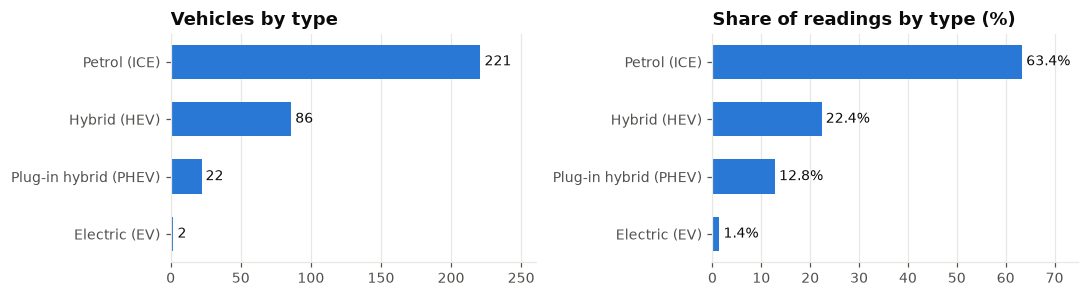

In [4]:
TYPE_ORDER = ["ICE", "HEV", "PHEV", "EV"]
TYPE_NAMES = {"ICE": "Petrol (ICE)", "HEV": "Hybrid (HEV)", "PHEV": "Plug-in hybrid (PHEV)", "EV": "Electric (EV)"}

by_vehicles = df.drop_duplicates("vehicle_id")["vehicle_type"].value_counts().reindex(TYPE_ORDER)
by_readings = df["vehicle_type"].value_counts(normalize=True).reindex(TYPE_ORDER) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 2.8))
for ax, values, title, fmt in [
    (axes[0], by_vehicles, "Vehicles by type", "{:.0f}"),
    (axes[1], by_readings, "Share of readings by type (%)", "{:.1f}%"),
]:
    labels = [TYPE_NAMES[t] for t in values.index]
    ax.barh(labels, values, color=BLUE, height=0.6)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(axis="y", visible=False)
    for y, v in enumerate(values):
        ax.text(v, y, " " + fmt.format(v), va="center", color=TEXT, fontsize=9)
    ax.set_xlim(0, values.max() * 1.18)
plt.tight_layout()

Most of the fleet is petrol cars, about a quarter are hybrids, and there are only **2 pure EVs** in these 4 weeks. Battery-related analysis therefore rests on a small number of vehicles.

median trip: 6.8 min | median gap between readings: 700 ms | 90% of gaps under 1600 ms


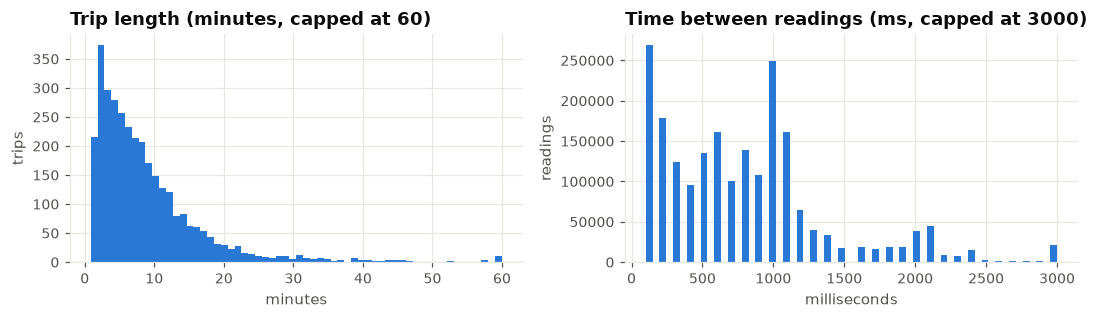

In [5]:
dt = df.groupby(TRIP)["time_ms"].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(trips["duration_min"].clip(upper=60), bins=60, color=BLUE)
axes[0].set_title("Trip length (minutes, capped at 60)")
axes[0].set_xlabel("minutes"); axes[0].set_ylabel("trips")

axes[1].hist(dt.clip(upper=3000), bins=60, color=BLUE)
axes[1].set_title("Time between readings (ms, capped at 3000)")
axes[1].set_xlabel("milliseconds"); axes[1].set_ylabel("readings")
plt.tight_layout()

print(f"median trip: {trips['duration_min'].median():.1f} min | "
      f"median gap between readings: {dt.median():.0f} ms | 90% of gaps under {dt.quantile(0.9):.0f} ms")

Trips are short (most under 15 minutes), and readings arrive roughly **once per second**. That rate is fine for slow-changing signals like fuel trims or battery voltage, but far too slow to see individual engine misfires, which happen within a single revolution.

## 3. Which signals are recorded

Not every car reports every signal: it depends on the vehicle and the logger. A signal counts as recorded in a trip if it is present in more than half of that trip's readings.

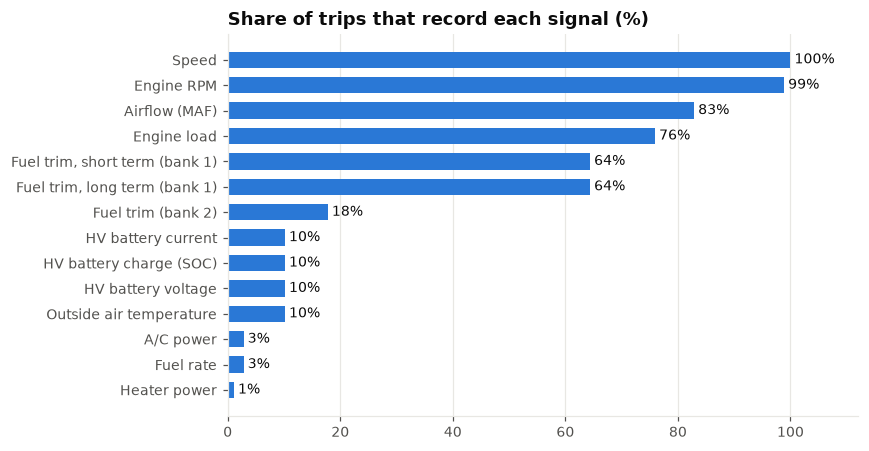

In [6]:
SIGNALS = {
    "speed_kmh": "Speed", "engine_rpm": "Engine RPM", "maf_gs": "Airflow (MAF)",
    "absolute_load_pct": "Engine load", "stft_b1_pct": "Fuel trim, short term (bank 1)",
    "ltft_b1_pct": "Fuel trim, long term (bank 1)", "stft_b2_pct": "Fuel trim (bank 2)",
    "outside_air_temp_c": "Outside air temperature", "hv_battery_voltage_v": "HV battery voltage",
    "hv_battery_current_a": "HV battery current", "hv_battery_soc_pct": "HV battery charge (SOC)",
    "fuel_rate_lph": "Fuel rate", "ac_power_kw": "A/C power", "heater_power_w": "Heater power",
}
recorded = df.groupby(TRIP)[list(SIGNALS)].agg(lambda s: s.notna().mean() > 0.5)
coverage = (recorded.mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh([SIGNALS[c] for c in coverage.index], coverage, color=BLUE, height=0.65)
ax.set_title("Share of trips that record each signal (%)")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, 112)
for y, v in enumerate(coverage):
    ax.text(v, y, f" {v:.0f}%", va="center", color=TEXT, fontsize=9)
plt.tight_layout()

In [7]:
by_type = recorded.join(trips.set_index(TRIP)["vehicle_type"]).groupby("vehicle_type").mean().T * 100
by_type = by_type[TYPE_ORDER].rename(index=SIGNALS, columns=TYPE_NAMES)
print("Share of trips recording each signal, by vehicle type (%)")
by_type.round(0).astype(int)

Share of trips recording each signal, by vehicle type (%)


vehicle_type,Petrol (ICE),Hybrid (HEV),Plug-in hybrid (PHEV),Electric (EV)
Speed,100,100,100,100
Engine RPM,100,100,100,0
Airflow (MAF),80,99,69,0
Engine load,79,99,0,0
"Fuel trim, short term (bank 1)",71,73,0,0
"Fuel trim, long term (bank 1)",71,73,0,0
Fuel trim (bank 2),27,2,0,0
Outside air temperature,0,0,100,100
HV battery voltage,0,0,100,100
HV battery current,0,0,100,100


Each vehicle type exposes a different set of signals:

- **Speed and RPM** are almost always present (EVs have no engine RPM).
- **Fuel trims** exist only on combustion engines, and **HV battery** signals only on plug-ins and EVs. Ordinary hybrids (HEV) do not report battery data here.
- No single trip has everything.

A single model over all signals would see missing values almost everywhere. This is why the analyzer uses **one detector per subsystem** (engine, speed, fuel, air, battery), runs only the ones the data supports, and lists the skipped checks in the report.

,stft_b1_pct,maf_gs
week starting,,
Nov 01,15.00,82.00
Nov 08,70.00,81.00
Nov 15,87.00,85.00
Nov 22,88.00,83.00


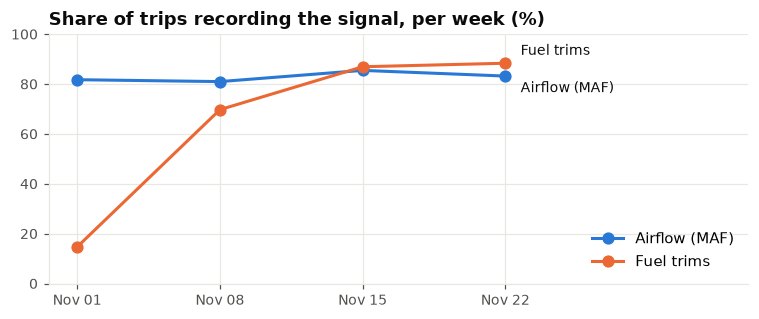

In [8]:
files = list_ved_files()[:WEEKS]
weekly = []
for path in files:
    week = df[df["timestamp"].dt.strftime("%y%m%d") >= path.name[4:10]]
    week = week[week["timestamp"] < pd.Timestamp("20" + path.name[4:10]) + pd.Timedelta(days=7)]
    rec = week.groupby(TRIP)[["stft_b1_pct", "maf_gs"]].agg(lambda s: s.notna().mean() > 0.5).mean() * 100
    weekly.append({"week starting": pd.Timestamp("20" + path.name[4:10]).strftime("%b %d"), **rec})
weekly = pd.DataFrame(weekly).set_index("week starting")

fig, ax = plt.subplots(figsize=(7, 3))
for column, color, name, nudge in [("maf_gs", BLUE, "Airflow (MAF)", -8), ("stft_b1_pct", ORANGE, "Fuel trims", 8)]:
    ax.plot(weekly.index, weekly[column], color=color, marker="o", markersize=7, label=name)
    ax.annotate(name, (len(weekly) - 1, weekly[column].iloc[-1]), xytext=(10, nudge),
                textcoords="offset points", va="center", color=TEXT, fontsize=9)
ax.set_ylim(0, 100); ax.set_xlim(-0.2, len(weekly) - 0.2 + 0.9)
ax.set_title("Share of trips recording the signal, per week (%)")
ax.legend(loc="lower right")
plt.tight_layout()
weekly.round(0)

**The logging changed after the first week.** Fuel trims were recorded in only about 15% of trips in week 1, but in 70–90% from week 2 onward, while airflow stayed steady. Any analysis of a single week can be misleading.

> **Impact on this project:** the included anomaly model was trained on week 1 only, so its fuel-system detector saw relatively few trips with fuel trims. Training on more weeks should improve it.

## 4. Signal distributions

The shaded band marks the central 98% of readings (1st to 99th percentile).

,median,1%,99%
signal,,,
Speed (km/h),41.00,0.00,113.77
Engine RPM (engine running),"1,355.00",498.80,"2,992.00"
"Airflow, MAF (g/s)",5.67,0.09,48.33
Short-term fuel trim (%),0.00,-12.50,15.62
"Total fuel trim, short + long (%)",0.78,-15.62,23.44
HV battery voltage (V),307.00,190.00,388.50


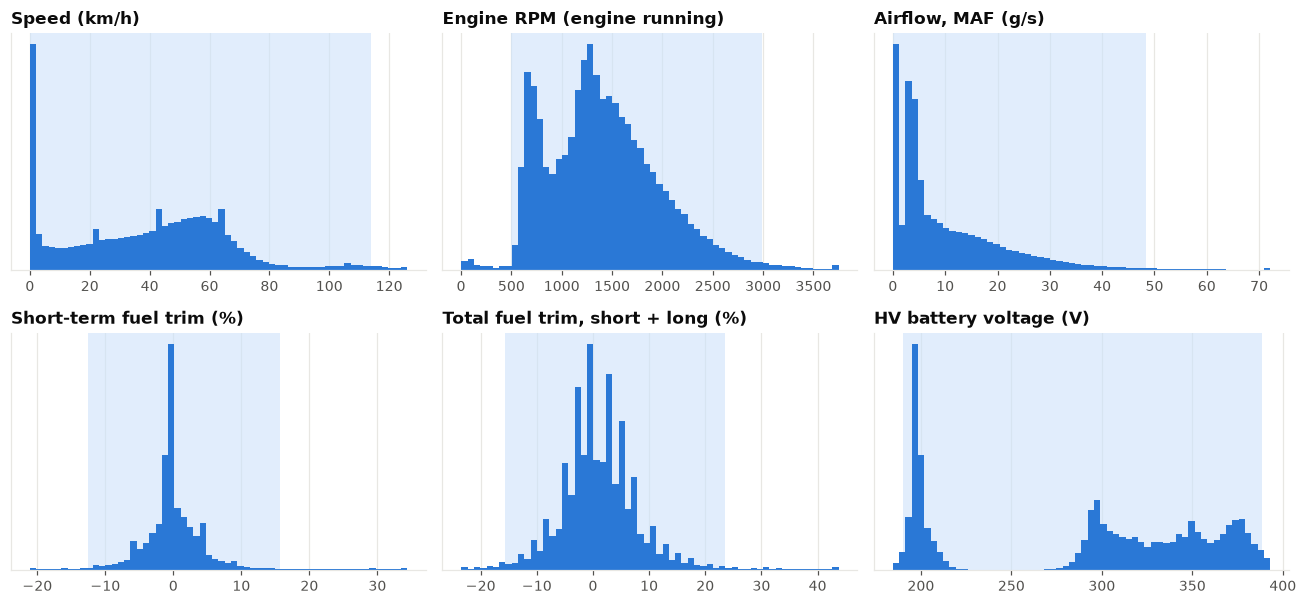

In [9]:
df["total_trim_b1_pct"] = df["stft_b1_pct"] + df["ltft_b1_pct"]
PANELS = [
    ("speed_kmh", "Speed (km/h)"), ("engine_rpm", "Engine RPM (engine running)"),
    ("maf_gs", "Airflow, MAF (g/s)"), ("stft_b1_pct", "Short-term fuel trim (%)"),
    ("total_trim_b1_pct", "Total fuel trim, short + long (%)"), ("hv_battery_voltage_v", "HV battery voltage (V)"),
]
fig, axes = plt.subplots(2, 3, figsize=(12, 5.6))
stats = []
for ax, (column, title) in zip(axes.flat, PANELS):
    values = df[column].dropna()
    if column == "engine_rpm":
        values = values[values > 0]
    low, high = values.quantile([0.01, 0.99])
    ax.axvspan(low, high, color=BAND, alpha=0.6, lw=0)
    ax.hist(values.clip(values.quantile(0.001), values.quantile(0.999)), bins=60, color=BLUE)
    ax.set_title(title, fontsize=11)
    ax.set_yticks([])
    stats.append({"signal": title, "median": values.median(), "1%": low, "99%": high})
plt.tight_layout()
pd.DataFrame(stats).set_index("signal")

- **Speed and RPM** show the usual mix of city driving and stops (the spike at 0 km/h).
- **Fuel trims** are centred near 0%: most of the time the engine needs only small corrections. The total trim (short + long term) still spans about −16% to +23% for 98% of readings, and the upper tail comes mostly from a few vehicles whose usual trim is high (section 5). A real ECU stores P0171 / P0172 at around ±25% total trim, so the gap between "unusual" and "fault code" is small for those vehicles.
- **Battery voltage** has several separate peaks, one per battery pack design, which already hints that "normal" depends on the vehicle.

## 5. Differences between vehicles

usual fuel trim across 291 vehicles: -10.9% to +24.2% (middle 50%: -1.6% to +3.1%)
usual battery voltage across 24 vehicles: 198 V to 381 V


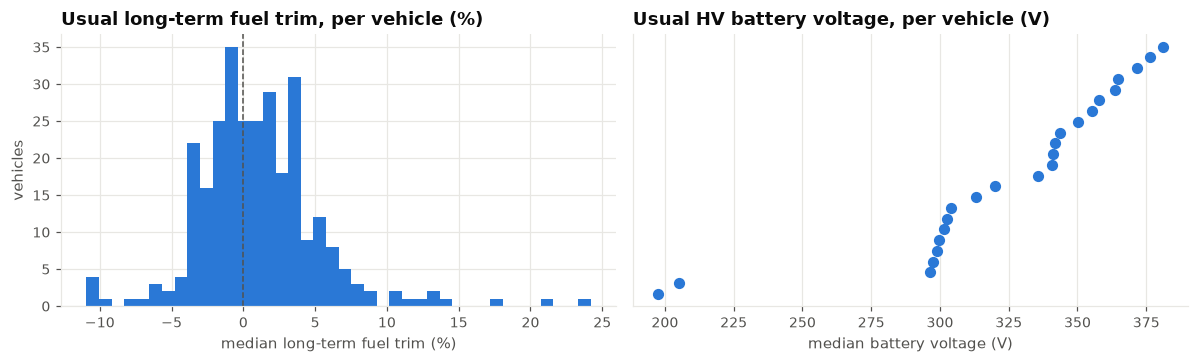

In [10]:
per_vehicle = df.groupby("vehicle_id").agg(
    vehicle_type=("vehicle_type", "first"),
    ltft=("ltft_b1_pct", "median"),
    hv_voltage=("hv_battery_voltage_v", "median"),
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
ltft = per_vehicle["ltft"].dropna()
axes[0].hist(ltft, bins=40, color=BLUE)
axes[0].axvline(0, color=TEXT_2, lw=1, ls="--")
axes[0].set_title("Usual long-term fuel trim, per vehicle (%)")
axes[0].set_xlabel("median long-term fuel trim (%)"); axes[0].set_ylabel("vehicles")

hv = per_vehicle.dropna(subset=["hv_voltage"]).sort_values("hv_voltage")
axes[1].scatter(hv["hv_voltage"], range(len(hv)), color=BLUE, s=40, zorder=3)
axes[1].set_title("Usual HV battery voltage, per vehicle (V)")
axes[1].set_xlabel("median battery voltage (V)"); axes[1].set_yticks([])
plt.tight_layout()

print(f"usual fuel trim across {len(ltft)} vehicles: {ltft.min():+.1f}% to {ltft.max():+.1f}% "
      f"(middle 50%: {ltft.quantile(.25):+.1f}% to {ltft.quantile(.75):+.1f}%)")
print(f"usual battery voltage across {len(hv)} vehicles: {hv['hv_voltage'].min():.0f} V to {hv['hv_voltage'].max():.0f} V")

**"Normal" depends on the vehicle.** Each engine settles at its own fuel trim level (half of vehicles between about −2% and +3%, but a few far outside, up to +24%, which may itself be a real lean condition), and battery packs run at very different voltages (about 200 V to 380 V). A fixed threshold would either flag healthy cars or miss real faults: a +10% trim is normal for some cars and a warning sign for others.

This is why the analyzer learns a **per-vehicle baseline** first and measures deviations from it.

## 6. Relationships between signals

Some checks rely on physics rather than single values.

**Airflow.** The air an engine takes in is roughly proportional to RPM × load, with a constant that depends on engine size. If the MAF sensor reads less than that relationship predicts, the sensor is drifting.

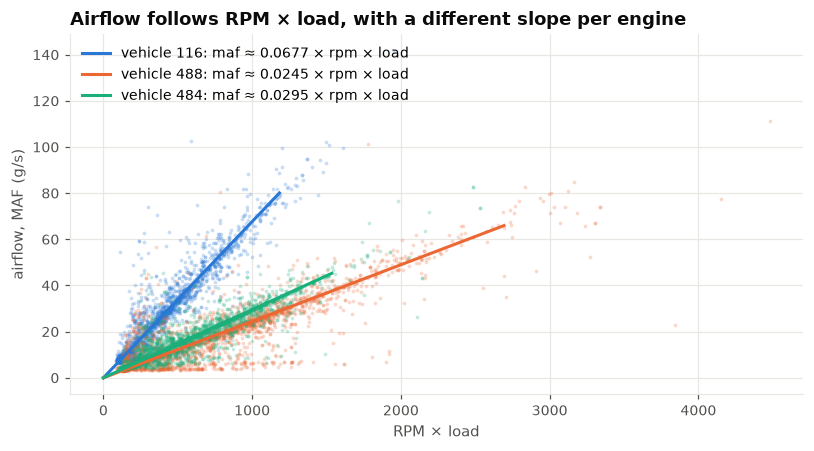

In [11]:
air = df[(df["engine_rpm"] > 500) & (df["absolute_load_pct"] > 5) & df["maf_gs"].notna()].copy()
air["rpm_x_load"] = air["engine_rpm"] * air["absolute_load_pct"] / 100
top = air["vehicle_id"].value_counts().index[:3]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for vid, color in zip(top, [BLUE, ORANGE, AQUA]):
    v = air[air["vehicle_id"] == vid].sample(3000, random_state=0)
    k = (v["maf_gs"] / v["rpm_x_load"]).median()
    ax.scatter(v["rpm_x_load"], v["maf_gs"], s=6, alpha=0.25, color=color, lw=0)
    xs = np.linspace(0, v["rpm_x_load"].quantile(0.99), 50)
    ax.plot(xs, k * xs, color=color, label=f"vehicle {vid}: maf ≈ {k:.4f} × rpm × load")
ax.set_xlabel("RPM × load"); ax.set_ylabel("airflow, MAF (g/s)")
ax.set_title("Airflow follows RPM × load, with a different slope per engine")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()

Each engine follows its own straight line, so one constant per vehicle (`VehicleBaseline.maf_k`) is enough to predict airflow. The analyzer flags a MAF sensor when readings fall well below that vehicle's line.

**Battery.** Under load, a battery's voltage drops in proportion to the current drawn (internal resistance). An ageing battery drops more.

fitted model: V = 197.4 + 0.32 × SOC + 0.066 × current
typical error of the model: ±1.5 V (median absolute residual)


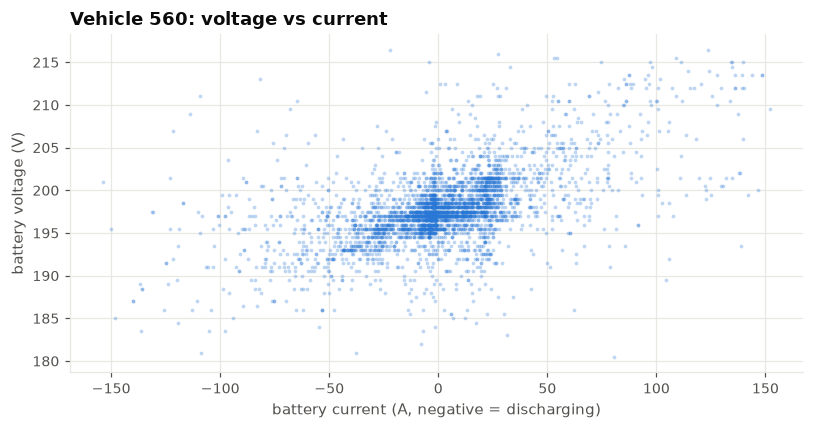

In [12]:
batt = df.dropna(subset=["hv_battery_voltage_v", "hv_battery_current_a", "hv_battery_soc_pct"])
vid = batt["vehicle_id"].value_counts().index[0]
b = batt[batt["vehicle_id"] == vid].sample(4000, random_state=0)

X = np.column_stack([np.ones(len(b)), b["hv_battery_soc_pct"], b["hv_battery_current_a"]])
coef, *_ = np.linalg.lstsq(X, b["hv_battery_voltage_v"], rcond=None)
residual = b["hv_battery_voltage_v"] - X @ coef

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.scatter(b["hv_battery_current_a"], b["hv_battery_voltage_v"], s=6, alpha=0.3, color=BLUE, lw=0)
ax.set_xlabel("battery current (A, negative = discharging)"); ax.set_ylabel("battery voltage (V)")
ax.set_title(f"Vehicle {vid}: voltage vs current")
plt.tight_layout()
print(f"fitted model: V = {coef[0]:.1f} + {coef[1]:.2f} × SOC + {coef[2]:.3f} × current")
print(f"typical error of the model: ±{residual.abs().median():.1f} V (median absolute residual)")

A simple linear model of voltage from charge level and current fits each vehicle well. The analyzer uses it as the battery baseline: a voltage well below the prediction means the battery is sagging. The model ignores temperature and ageing within a trip, which is the main source of false battery alarms.

## 7. One example trip

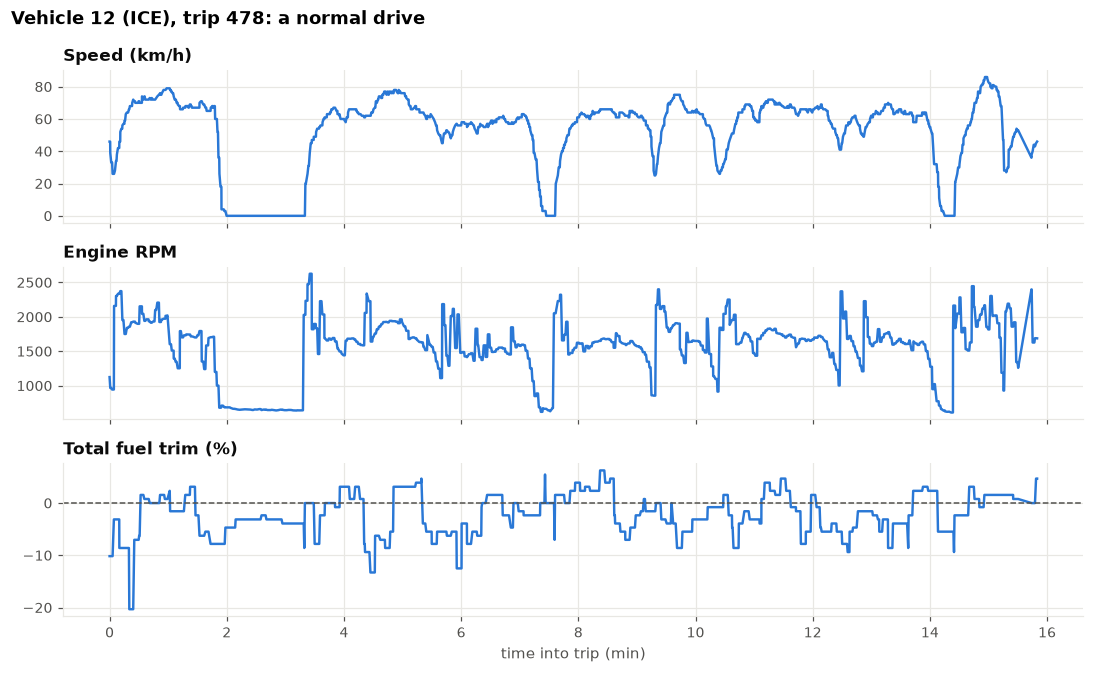

In [13]:
candidates = trips[trips["duration_min"].between(10, 20) & (trips["vehicle_type"] == "ICE")]
has_trims = recorded["stft_b1_pct"].reindex(candidates.set_index(TRIP).index).fillna(False).to_numpy()
example = candidates[has_trims].iloc[0]
trip = df[(df["vehicle_id"] == example.vehicle_id) & (df["trip_id"] == example.trip_id)]
minutes = (trip["time_ms"] - trip["time_ms"].min()) / 60_000

fig, axes = plt.subplots(3, 1, figsize=(10, 6.2), sharex=True)
for ax, (column, title) in zip(axes, [("speed_kmh", "Speed (km/h)"), ("engine_rpm", "Engine RPM"),
                                      ("total_trim_b1_pct", "Total fuel trim (%)")]):
    ax.plot(minutes, trip[column], color=BLUE, lw=1.6)
    ax.set_title(title, fontsize=11)
axes[2].axhline(0, color=TEXT_2, lw=1, ls="--")
axes[2].set_xlabel("time into trip (min)")
fig.suptitle(f"Vehicle {example.vehicle_id} ({example.vehicle_type}), trip {example.trip_id}: a normal drive",
             x=0.01, ha="left", fontweight="bold")
plt.tight_layout()

A normal drive in a petrol car: RPM follows speed (with gear changes), and the fuel trim moves around a stable level close to 0%. In hybrids, RPM would also drop to 0 whenever the engine switches off. The synthetic faults in notebook 2 are injected into trips like this one.

## 8. Data quality

In [14]:
_, invalid = remove_invalid_values(raw.rename(columns={}))
duplicates = raw.duplicated(["vehicle_id", "trip_id", "time_ms"]).sum()
no_signal = (raw["speed_kmh"].isna() & raw["engine_rpm"].isna()).sum()

quality = pd.DataFrame([
    {"issue": "duplicate readings", "count": duplicates, "action": "removed"},
    {"issue": "rows with neither speed nor RPM", "count": no_signal, "action": "removed"},
    *[{"issue": f"impossible {col} (outside {VALID_RANGES[col]})", "count": n, "action": "set to missing"}
      for col, n in invalid.items()],
]).set_index("issue")
quality

,count,action
issue,,
duplicate readings,0,removed
rows with neither speed nor RPM,1396,removed
"impossible absolute_load_pct (outside (0, 400))",30,set to missing


VED is clean: no duplicate readings, a small number of empty rows and a handful of impossible engine-load values (above 400%). The cleaning step handles these, so the main data challenge is **missing signals**, not wrong ones.

## 9. Summary: findings → design decisions

| Finding | Design decision in the analyzer |
|---|---|
| Each vehicle type records a different set of signals; no trip has all of them | One detector per subsystem; the report lists skipped checks |
| Fuel trim coverage jumped from ~15% to 70–90% of trips after week 1 | Train on several weeks; the included model (week 1 only) is conservative for fuel faults |
| Usual fuel trim and battery voltage differ widely between vehicles | Per-vehicle baselines; features measure deviation from them |
| Airflow ≈ constant × RPM × load per engine; voltage ≈ linear in SOC and current | Physics-based residuals for the air and battery checks |
| About 1 reading per second | Fine for trims and voltage; misfire detection is limited |
| VED has no fault codes | Faults are simulated on real trips (notebook 2) |
| Very few impossible values | Simple range-based cleaning is enough |

**Next:** `02_synthetic_faults.ipynb`, how faults are injected into these trips.